# Empirical Analysis: Climate Risk & U.S. Loan Portfolios

**Phase 1 — Data exploration, stationarity, and baseline models**

This notebook establishes the empirical foundation for the climate-risk-loans project:
1. Load and inspect FRED loan & macro series
2. Compute log growth rates (course convention: $100 \times \ln(Y_t / Y_{t-1})$)
3. Stationarity testing (ADF, KPSS)
4. ACF/PACF analysis
5. COVID structural break investigation
6. AR baseline models via AIC/BIC
7. Cross-correlation between loan growth and macro variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
SAVE_DPI = 300
FIG_DIR = 'outputs/figures/'
DATA_DIR = 'data/raw/'

## 1. Load Data

In [2]:
# Load all FRED series
series_info = {
    'BUSLOANS':  'C&I Loans (Billions $)',
    'CONSUMER':  'Consumer Loans (Billions $)',
    'GDPC1':     'Real GDP (Billions 2017$)',
    'UNRATE':    'Unemployment Rate (%)',
    'FEDFUNDS':  'Fed Funds Rate (%)',
    'DGS10':     '10-Year Treasury Yield (%)',
    'CPIAUCSL':  'CPI (Index)',
}

data = {}
for ticker, label in series_info.items():
    df = pd.read_csv(f'{DATA_DIR}{ticker}.csv', parse_dates=['date'], index_col='date')
    df.columns = [ticker]
    # Drop any missing/placeholder values
    df = df.replace('.', np.nan).dropna()
    df[ticker] = df[ticker].astype(float)
    data[ticker] = df
    print(f'{ticker:12s} | {label:35s} | {df.index[0].date()} to {df.index[-1].date()} | n={len(df)} | freq~{"Q" if ticker=="GDPC1" else "M"}')

BUSLOANS     | C&I Loans (Billions $)              | 1947-01-01 to 2025-12-01 | n=948 | freq~M
CONSUMER     | Consumer Loans (Billions $)         | 1947-01-01 to 2025-12-01 | n=948 | freq~M
GDPC1        | Real GDP (Billions 2017$)           | 1947-01-01 to 2025-07-01 | n=315 | freq~Q
UNRATE       | Unemployment Rate (%)               | 1948-01-01 to 2026-01-01 | n=936 | freq~M
FEDFUNDS     | Fed Funds Rate (%)                  | 1954-07-01 to 2026-01-01 | n=859 | freq~M
DGS10        | 10-Year Treasury Yield (%)          | 1962-01-02 to 2026-02-11 | n=16012 | freq~M
CPIAUCSL     | CPI (Index)                         | 1947-01-01 to 2026-01-01 | n=948 | freq~M


## 2. Levels — Visual Inspection

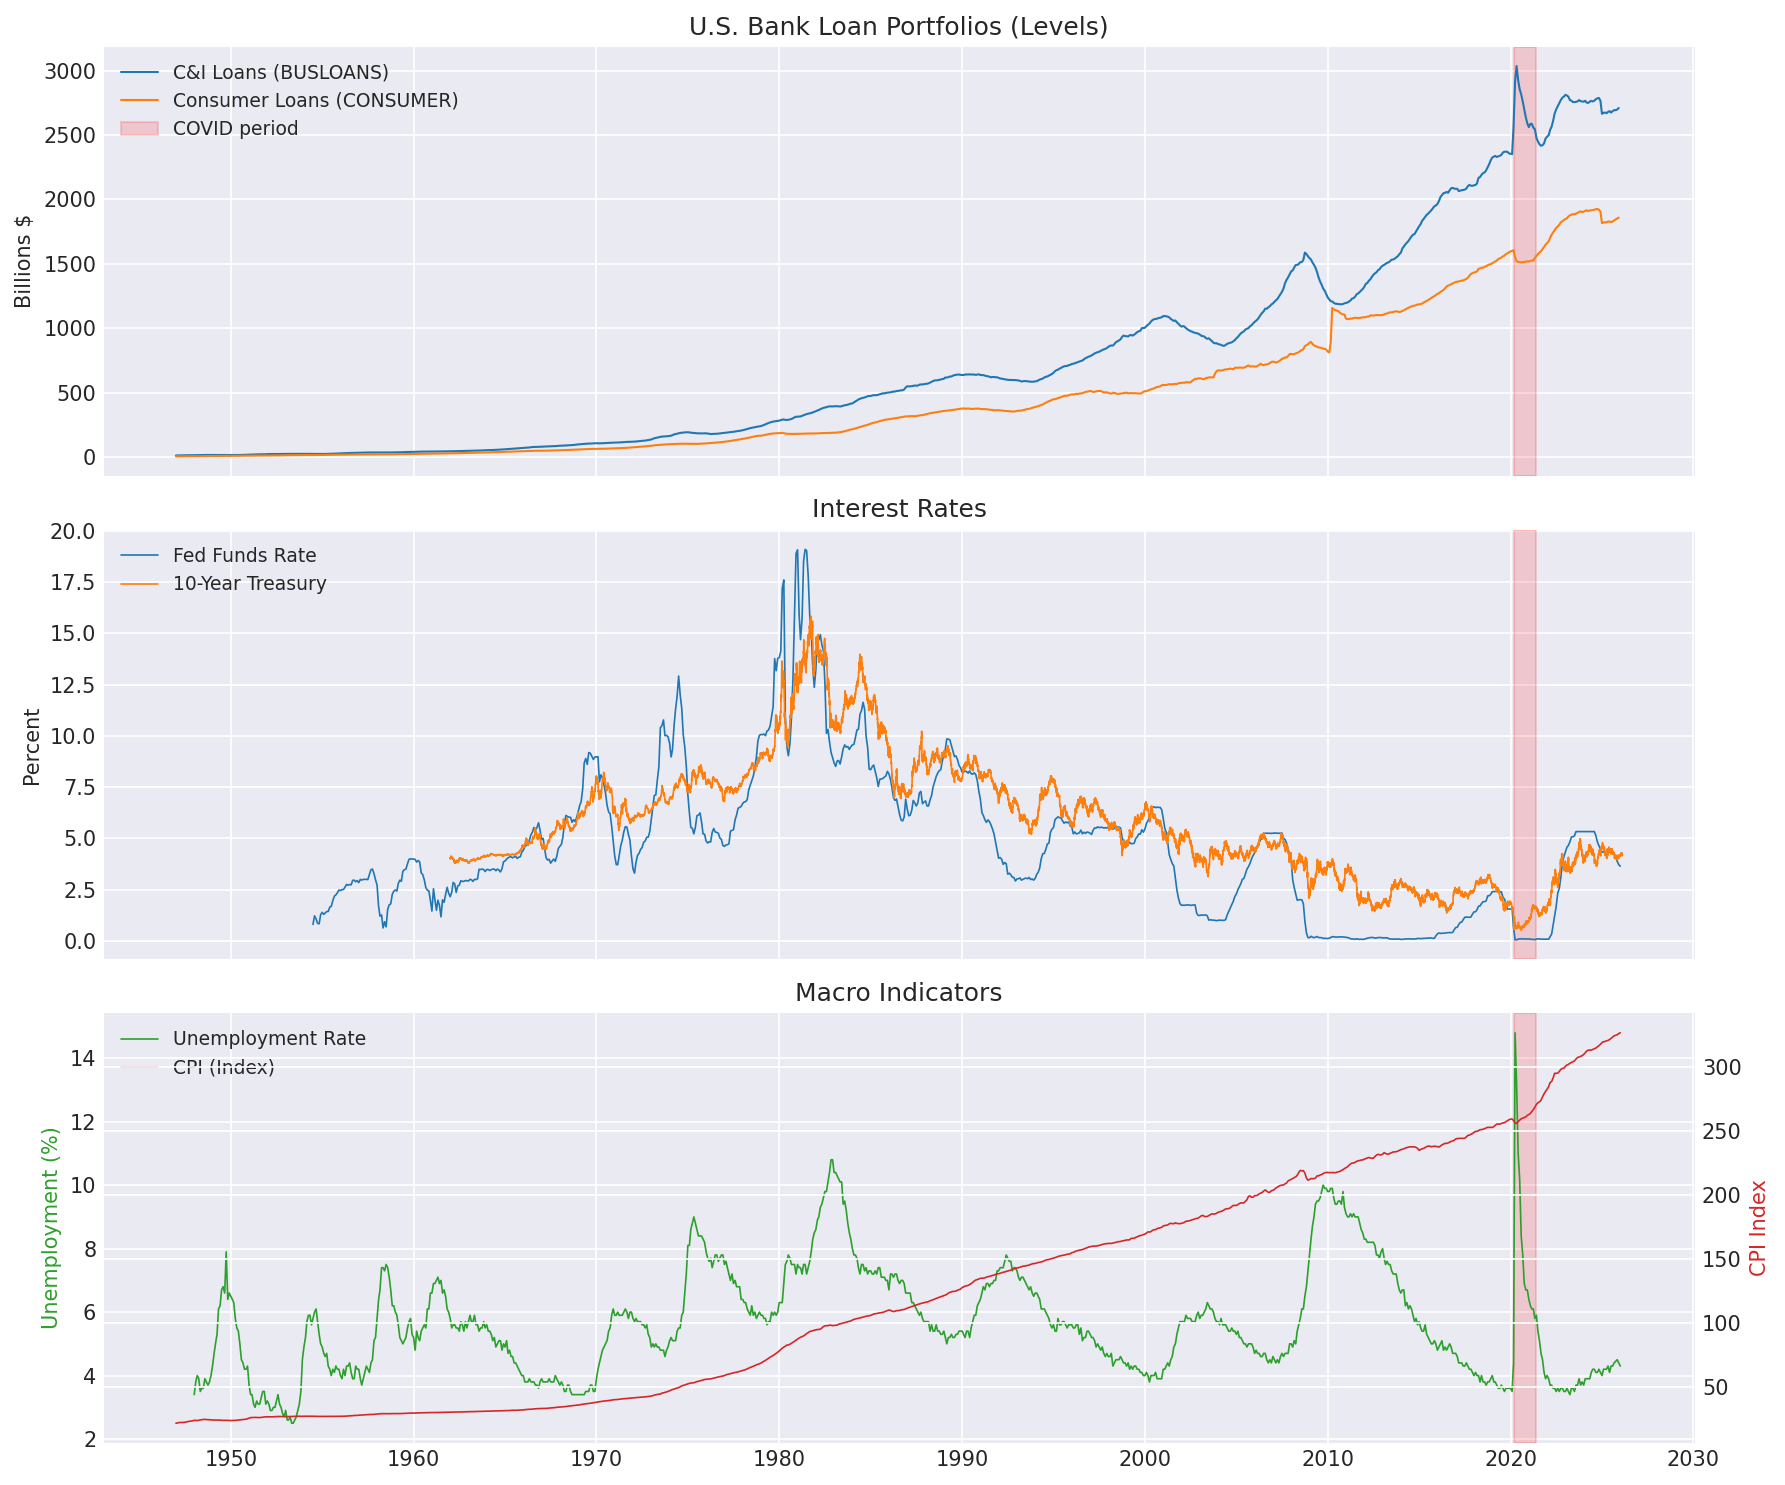

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel A: Loan series
ax = axes[0]
ax.plot(data['BUSLOANS'].index, data['BUSLOANS']['BUSLOANS'], label='C&I Loans (BUSLOANS)', linewidth=1)
ax.plot(data['CONSUMER'].index, data['CONSUMER']['CONSUMER'], label='Consumer Loans (CONSUMER)', linewidth=1)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), alpha=0.15, color='red', label='COVID period')
ax.set_ylabel('Billions $')
ax.set_title('U.S. Bank Loan Portfolios (Levels)')
ax.legend(fontsize=9)

# Panel B: Interest rates
ax = axes[1]
ax.plot(data['FEDFUNDS'].index, data['FEDFUNDS']['FEDFUNDS'], label='Fed Funds Rate', linewidth=0.8)
ax.plot(data['DGS10'].index, data['DGS10']['DGS10'], label='10-Year Treasury', linewidth=0.8)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), alpha=0.15, color='red')
ax.set_ylabel('Percent')
ax.set_title('Interest Rates')
ax.legend(fontsize=9)

# Panel C: Macro
ax = axes[2]
ax2 = ax.twinx()
ax.plot(data['UNRATE'].index, data['UNRATE']['UNRATE'], label='Unemployment Rate', color='C2', linewidth=0.8)
ax2.plot(data['CPIAUCSL'].index, data['CPIAUCSL']['CPIAUCSL'], label='CPI (Index)', color='C3', linewidth=0.8)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), alpha=0.15, color='red')
ax.set_ylabel('Unemployment (%)', color='C2')
ax2.set_ylabel('CPI Index', color='C3')
ax.set_title('Macro Indicators')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}levels_overview.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 3. Log Growth Rates

Course convention: $g_t = 100 \times \ln(Y_t / Y_{t-1})$

This is the month-over-month percentage growth rate (approximately). For the loan series, this is the key transformation to achieve stationarity.

In [4]:
# Compute log growth rates for loan series
growth = pd.DataFrame(index=data['BUSLOANS'].index)
growth['BUSLOANS_g'] = 100 * np.log(data['BUSLOANS']['BUSLOANS'] / data['BUSLOANS']['BUSLOANS'].shift(1))
growth['CONSUMER_g'] = 100 * np.log(data['CONSUMER']['CONSUMER'] / data['CONSUMER']['CONSUMER'].shift(1))

# Also compute for CPI (inflation rate)
cpi = data['CPIAUCSL'].copy()
cpi['CPI_g'] = 100 * np.log(cpi['CPIAUCSL'] / cpi['CPIAUCSL'].shift(1))

growth = growth.dropna()
print('Growth rate summary statistics:')
print(growth.describe().round(4))

Growth rate summary statistics:
       BUSLOANS_g  CONSUMER_g
count    947.0000    947.0000
mean       0.5787      0.6443
std        1.0585      1.1804
min       -3.7340     -4.7639
25%        0.0414      0.1854
50%        0.5819      0.5585
75%        1.0789      1.0243
max       13.0203     26.6756


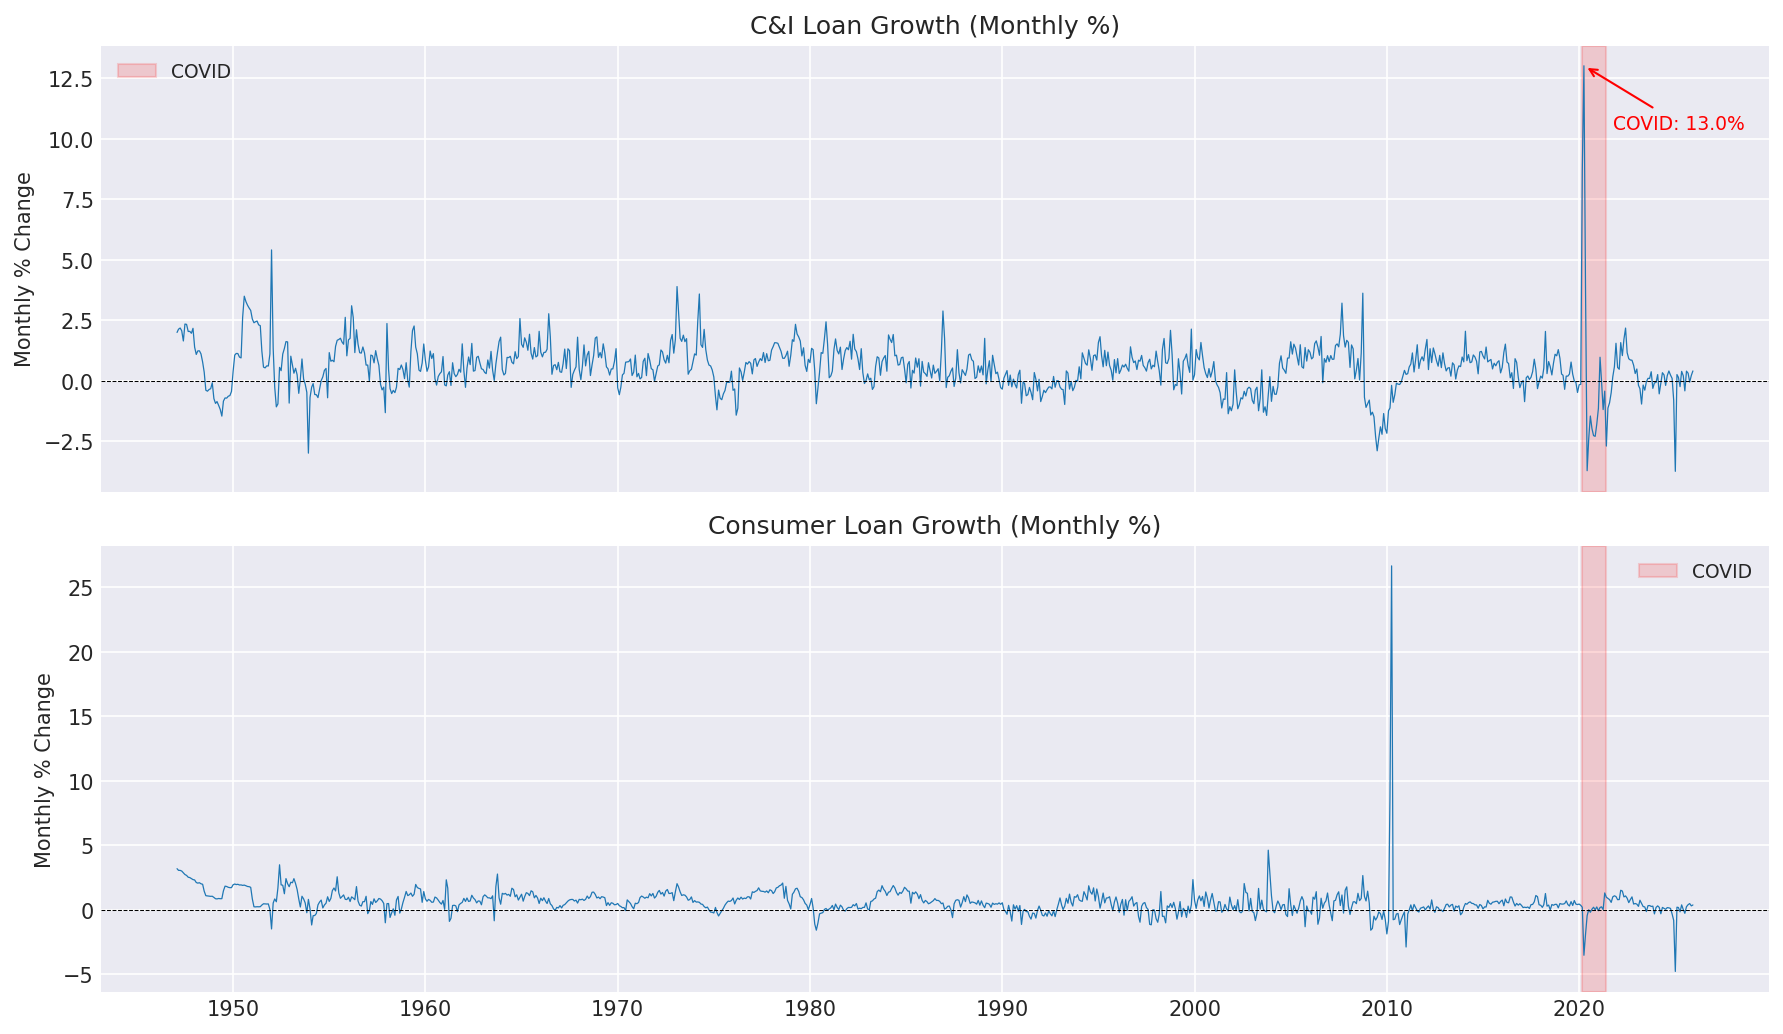

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, col, title in zip(axes, ['BUSLOANS_g', 'CONSUMER_g'],
                           ['C&I Loan Growth (Monthly %)', 'Consumer Loan Growth (Monthly %)']):
    ax.plot(growth.index, growth[col], linewidth=0.6, color='C0')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), alpha=0.15, color='red', label='COVID')
    # Mark the COVID spike
    covid_mask = (growth.index >= '2020-03-01') & (growth.index <= '2020-06-01')
    if growth.loc[covid_mask, col].abs().max() > 3 * growth[col].std():
        peak_date = growth.loc[covid_mask, col].abs().idxmax()
        peak_val = growth.loc[peak_date, col]
        ax.annotate(f'COVID: {peak_val:.1f}%', xy=(peak_date, peak_val),
                    xytext=(peak_date + pd.DateOffset(months=18), peak_val * 0.8),
                    arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')
    ax.set_ylabel('Monthly % Change')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}growth_rates.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 4. Stationarity Tests

We apply the ADF test (H0: unit root) and KPSS test (H0: stationary) to both levels and growth rates. The combination helps resolve ambiguity — if ADF rejects and KPSS fails to reject, we have strong evidence of stationarity.

In [6]:
def stationarity_tests(series, name):
    """Run ADF and KPSS tests, return results as dict."""
    s = series.dropna()
    # ADF
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(s, autolag='AIC')
    # KPSS
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(s, regression='c', nlags='auto')
    return {
        'Series': name,
        'ADF Stat': adf_stat,
        'ADF p-val': adf_p,
        'ADF Lags': adf_lags,
        'ADF 5% CV': adf_crit['5%'],
        'KPSS Stat': kpss_stat,
        'KPSS p-val': kpss_p,
        'KPSS 5% CV': kpss_crit['5%'],
        'Conclusion': ''
    }

results = []

# Levels
for ticker in ['BUSLOANS', 'CONSUMER']:
    r = stationarity_tests(data[ticker][ticker], f'{ticker} (level)')
    r['Conclusion'] = 'Unit root' if r['ADF p-val'] > 0.05 else 'Stationary'
    if r['KPSS p-val'] < 0.05:
        r['Conclusion'] = 'Unit root (KPSS confirms)'
    results.append(r)

# Growth rates
for col, name in [('BUSLOANS_g', 'BUSLOANS growth'), ('CONSUMER_g', 'CONSUMER growth')]:
    r = stationarity_tests(growth[col], name)
    if r['ADF p-val'] < 0.05 and r['KPSS p-val'] > 0.05:
        r['Conclusion'] = 'Stationary (both confirm)'
    elif r['ADF p-val'] < 0.05:
        r['Conclusion'] = 'Stationary (ADF)'
    else:
        r['Conclusion'] = 'Ambiguous'
    results.append(r)

# Macro series
for ticker in ['UNRATE', 'FEDFUNDS']:
    r = stationarity_tests(data[ticker][ticker], f'{ticker} (level)')
    r['Conclusion'] = 'Unit root' if r['ADF p-val'] > 0.05 else 'Stationary'
    results.append(r)

results_df = pd.DataFrame(results)
display_cols = ['Series', 'ADF Stat', 'ADF p-val', 'ADF Lags', 'KPSS Stat', 'KPSS p-val', 'Conclusion']
print(results_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))

          Series  ADF Stat  ADF p-val  ADF Lags  KPSS Stat  KPSS p-val                Conclusion
BUSLOANS (level)    2.1270     0.9988        19     4.1021      0.0100 Unit root (KPSS confirms)
CONSUMER (level)    3.4683     1.0000         2     4.0830      0.0100 Unit root (KPSS confirms)
 BUSLOANS growth   -6.8942     0.0000        12     0.6480      0.0183          Stationary (ADF)
 CONSUMER growth  -11.5528     0.0000         3     1.6141      0.0100          Stationary (ADF)
  UNRATE (level)   -3.9368     0.0018         1     0.4060      0.0746                Stationary
FEDFUNDS (level)   -2.9950     0.0354        17     1.2488      0.0100                Stationary


## 5. ACF/PACF — Loan Growth Rates

The ACF and PACF patterns help identify candidate AR/MA orders for baseline models.

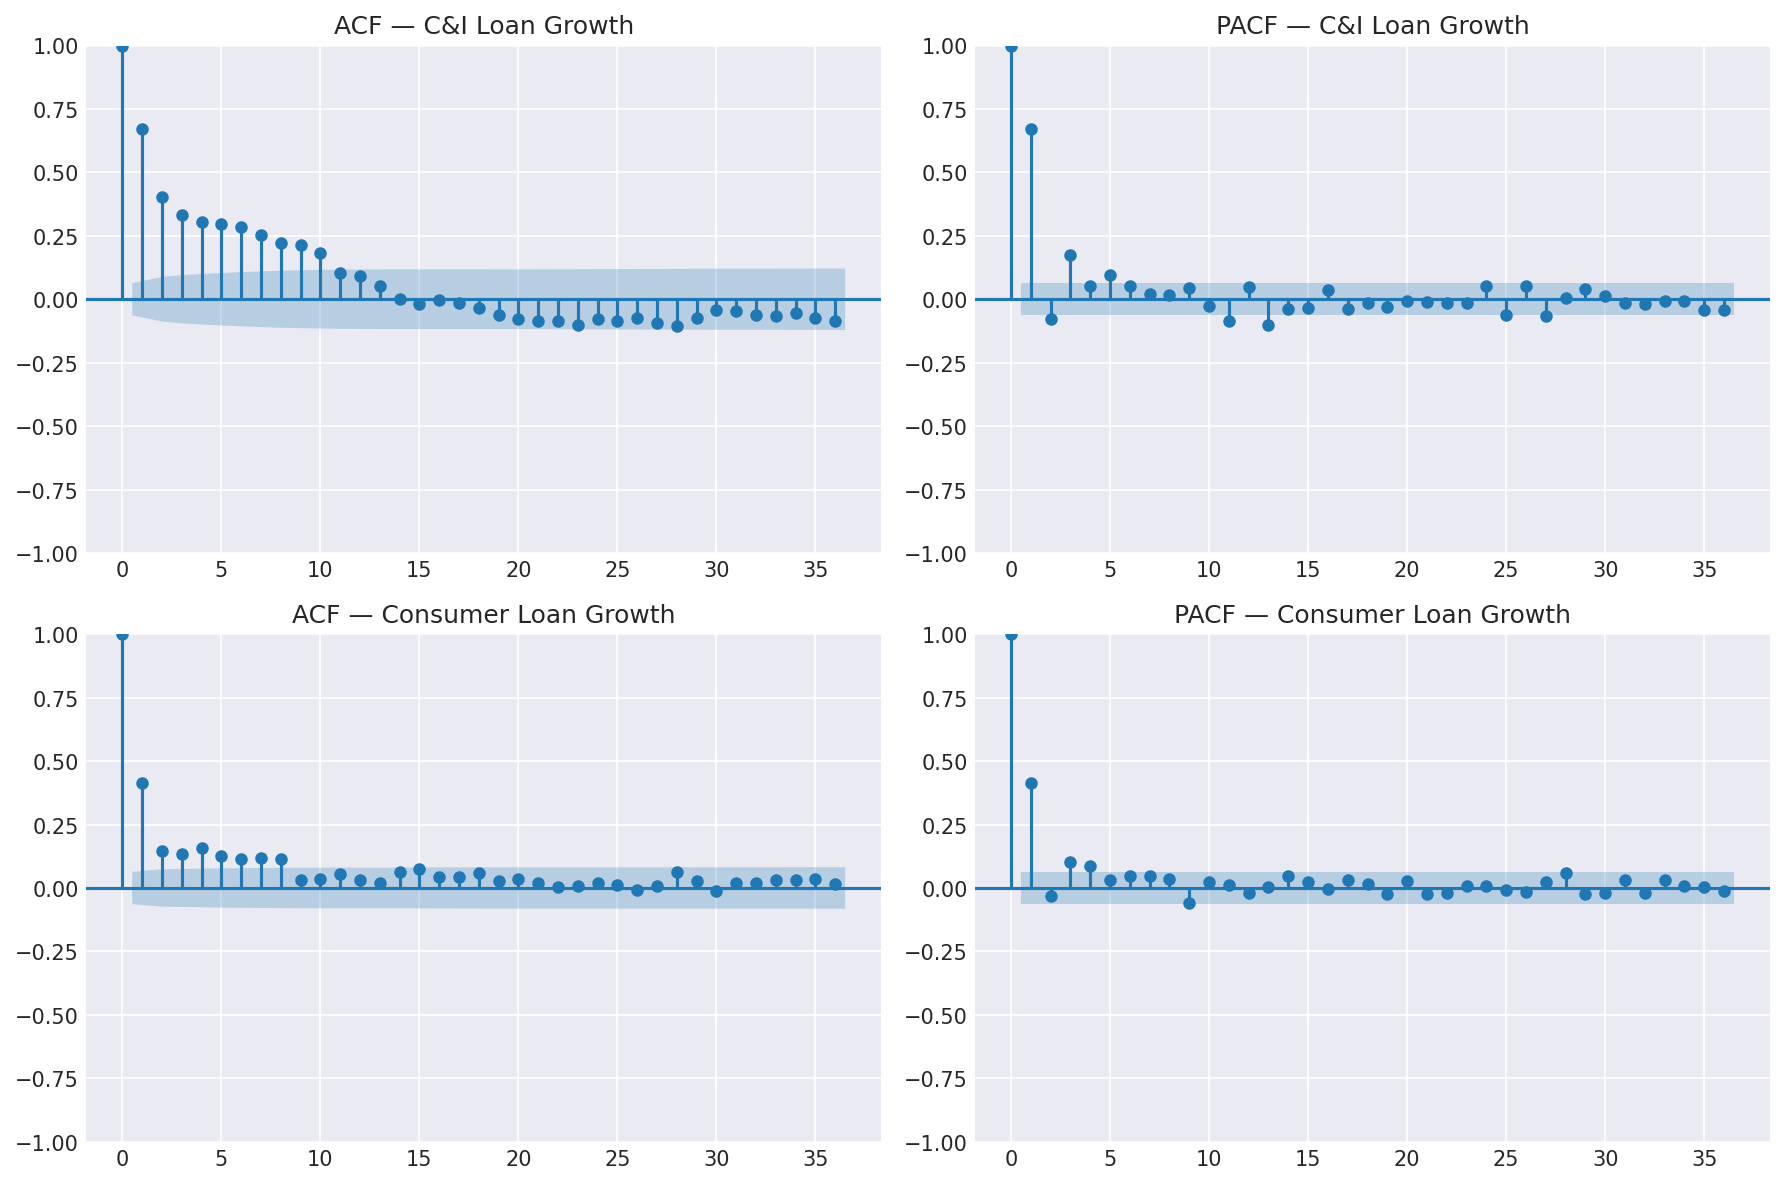

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, (col, title) in enumerate([('BUSLOANS_g', 'C&I Loan Growth'),
                                    ('CONSUMER_g', 'Consumer Loan Growth')]):
    plot_acf(growth[col].dropna(), ax=axes[i, 0], lags=36, title=f'ACF — {title}')
    plot_pacf(growth[col].dropna(), ax=axes[i, 1], lags=36, title=f'PACF — {title}', method='ywm')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}acf_pacf_growth.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 6. COVID Structural Break Investigation

BofA flagged COVID treatment as a key modeling decision. Let's quantify the break.

In [8]:
# Define periods
pre_covid = growth.loc[:'2020-02-01']
covid_period = growth.loc['2020-03-01':'2021-06-01']
post_covid = growth.loc['2021-07-01':]

print('=== BUSLOANS Growth Rate Statistics by Period ===')
for period, label in [(pre_covid, 'Pre-COVID (1947-2020)'),
                       (covid_period, 'COVID (Mar 2020 - Jun 2021)'),
                       (post_covid, 'Post-COVID (Jul 2021 - Dec 2025)')]:
    s = period['BUSLOANS_g']
    print(f'\n{label}:')
    print(f'  Mean: {s.mean():.4f}%   Std: {s.std():.4f}%   Min: {s.min():.2f}%   Max: {s.max():.2f}%   n={len(s)}')

print('\n=== CONSUMER Growth Rate Statistics by Period ===')
for period, label in [(pre_covid, 'Pre-COVID (1947-2020)'),
                       (covid_period, 'COVID (Mar 2020 - Jun 2021)'),
                       (post_covid, 'Post-COVID (Jul 2021 - Dec 2025)')]:
    s = period['CONSUMER_g']
    print(f'\n{label}:')
    print(f'  Mean: {s.mean():.4f}%   Std: {s.std():.4f}%   Min: {s.min():.2f}%   Max: {s.max():.2f}%   n={len(s)}')

=== BUSLOANS Growth Rate Statistics by Period ===

Pre-COVID (1947-2020):
  Mean: 0.6087%   Std: 0.8955%   Min: -2.98%   Max: 5.41%   n=877

COVID (Mar 2020 - Jun 2021):
  Mean: 0.3300%   Std: 4.5347%   Min: -3.71%   Max: 13.02%   n=16

Post-COVID (Jul 2021 - Dec 2025):
  Mean: 0.1655%   Std: 0.8455%   Min: -3.73%   Max: 2.18%   n=54

=== CONSUMER Growth Rate Statistics by Period ===

Pre-COVID (1947-2020):
  Mean: 0.6788%   Std: 1.1921%   Min: -2.87%   Max: 26.68%   n=877

COVID (Mar 2020 - Jun 2021):
  Mean: -0.1609%   Std: 1.1179%   Min: -3.51%   Max: 1.32%   n=16

Post-COVID (Jul 2021 - Dec 2025):
  Mean: 0.3229%   Std: 0.8404%   Min: -4.76%   Max: 1.53%   n=54


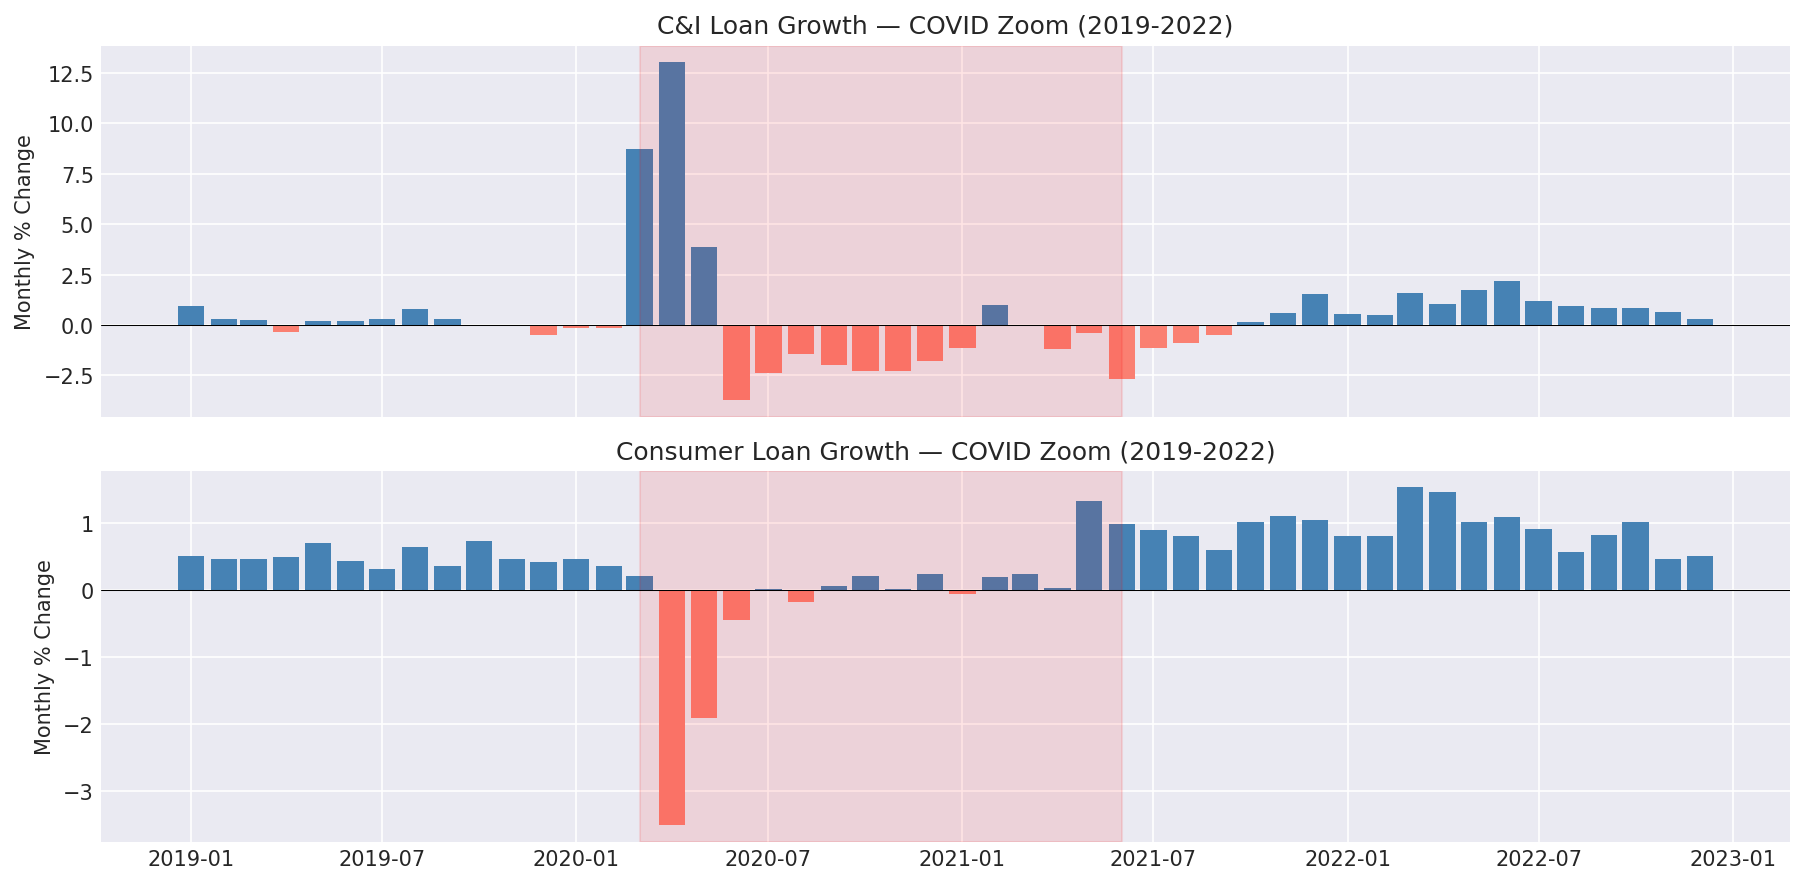

In [9]:
# Zoom into COVID period
zoom = growth.loc['2019-01-01':'2022-12-01']

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, col, title in zip(axes, ['BUSLOANS_g', 'CONSUMER_g'],
                           ['C&I Loan Growth', 'Consumer Loan Growth']):
    ax.bar(zoom.index, zoom[col], width=25, color=np.where(zoom[col] >= 0, 'steelblue', 'salmon'))
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), alpha=0.1, color='red')
    ax.set_ylabel('Monthly % Change')
    ax.set_title(f'{title} — COVID Zoom (2019-2022)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}covid_zoom.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

In [10]:
# COVID outlier magnitude: how many standard deviations?
for col, name in [('BUSLOANS_g', 'BUSLOANS'), ('CONSUMER_g', 'CONSUMER')]:
    pre_mean = pre_covid[col].mean()
    pre_std = pre_covid[col].std()
    covid_vals = covid_period[col]
    z_scores = (covid_vals - pre_mean) / pre_std
    extreme = z_scores[z_scores.abs() > 3]
    print(f'\n{name} — COVID observations exceeding 3 sigma (pre-COVID baseline):')
    for date, z in extreme.items():
        print(f'  {date.strftime("%Y-%m")}: z = {z:.1f} sigma  (growth = {covid_vals.loc[date]:.2f}%)')


BUSLOANS — COVID observations exceeding 3 sigma (pre-COVID baseline):
  2020-03: z = 9.0 sigma  (growth = 8.70%)
  2020-04: z = 13.9 sigma  (growth = 13.02%)
  2020-05: z = 3.6 sigma  (growth = 3.86%)
  2020-06: z = -4.8 sigma  (growth = -3.71%)
  2020-07: z = -3.4 sigma  (growth = -2.39%)
  2020-10: z = -3.2 sigma  (growth = -2.26%)
  2020-11: z = -3.2 sigma  (growth = -2.29%)
  2021-06: z = -3.7 sigma  (growth = -2.69%)

CONSUMER — COVID observations exceeding 3 sigma (pre-COVID baseline):
  2020-04: z = -3.5 sigma  (growth = -3.51%)


## 7. AR Baseline Models (AIC/BIC Selection)

Fit AR(p) models to loan growth rates using information criteria, following course methods (Weeks 3-4). We estimate on the **full sample** and a **post-1990 subsample** to check robustness.

We also test an **ex-COVID** sample (dropping Mar 2020 – Jun 2021) to assess sensitivity to the structural break.

In [11]:
def ar_selection(series, max_p=12, series_name=''):
    """Select AR order by AIC and BIC."""
    s = series.dropna()
    results = []
    for p in range(1, max_p + 1):
        try:
            model = AutoReg(s, lags=p, old_names=False).fit()
            results.append({'p': p, 'AIC': model.aic, 'BIC': model.bic})
        except Exception:
            continue
    res_df = pd.DataFrame(results)
    best_aic = res_df.loc[res_df['AIC'].idxmin()]
    best_bic = res_df.loc[res_df['BIC'].idxmin()]
    print(f'{series_name}: AIC selects AR({int(best_aic["p"])}), BIC selects AR({int(best_bic["p"])})')
    return res_df, int(best_aic['p']), int(best_bic['p'])

print('=== Full Sample (1947-2025) ===')
bus_full, bus_aic_p, bus_bic_p = ar_selection(growth['BUSLOANS_g'], series_name='BUSLOANS')
con_full, con_aic_p, con_bic_p = ar_selection(growth['CONSUMER_g'], series_name='CONSUMER')

print('\n=== Post-1990 Sample ===')
g90 = growth.loc['1990-01-01':]
ar_selection(g90['BUSLOANS_g'], series_name='BUSLOANS (post-1990)')
ar_selection(g90['CONSUMER_g'], series_name='CONSUMER (post-1990)')

print('\n=== Ex-COVID Sample (drop Mar 2020 - Jun 2021) ===')
g_excovid = growth.loc[(growth.index < '2020-03-01') | (growth.index > '2021-06-01')]
ar_selection(g_excovid['BUSLOANS_g'], series_name='BUSLOANS (ex-COVID)')
ar_selection(g_excovid['CONSUMER_g'], series_name='CONSUMER (ex-COVID)')

=== Full Sample (1947-2025) ===
BUSLOANS: AIC selects AR(12), BIC selects AR(5)


/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-pa

/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-pa

CONSUMER: AIC selects AR(12), BIC selects AR(4)

=== Post-1990 Sample ===
BUSLOANS (post-1990): AIC selects AR(11), BIC selects AR(3)
CONSUMER (post-1990): AIC selects AR(12), BIC selects AR(2)

=== Ex-COVID Sample (drop Mar 2020 - Jun 2021) ===
BUSLOANS (ex-COVID): AIC selects AR(12), BIC selects AR(12)
CONSUMER (ex-COVID): AIC selects AR(12), BIC selects AR(4)


/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-pa

(     p          AIC          BIC
 0    1  2773.253221  2787.758775
 1    2  2770.631500  2789.967935
 2    3  2758.707517  2782.872676
 3    4  2750.241636  2779.233357
 4    5  2748.264657  2782.080777
 5    6  2745.020716  2783.659066
 6    7  2742.167782  2785.626190
 7    8  2740.151533  2788.427825
 8    9  2736.408136  2789.500133
 9   10  2735.239590  2793.145110
 10  11  2734.620211  2797.337068
 11  12  2733.931480  2801.457486,
 12,
 4)

In [12]:
# Fit the BIC-selected model on ex-COVID sample and inspect
# Use BIC (more parsimonious) as baseline
for col, name in [('BUSLOANS_g', 'C&I Loans'), ('CONSUMER_g', 'Consumer Loans')]:
    s = g_excovid[col].dropna()
    _, _, bic_p = ar_selection(s, series_name=f'{name} (ex-COVID)', max_p=12)
    model = AutoReg(s, lags=bic_p, old_names=False).fit()
    print(f'\n--- AR({bic_p}) for {name} Growth (ex-COVID) ---')
    print(model.summary().tables[1])
    
    # Ljung-Box test on residuals
    lb = acorr_ljungbox(model.resid, lags=[6, 12, 24], return_df=True)
    print(f'\nLjung-Box test on residuals:')
    print(lb.to_string(float_format='{:.4f}'.format))

C&I Loans (ex-COVID): AIC selects AR(12), BIC selects AR(12)

--- AR(12) for C&I Loans Growth (ex-COVID) ---
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1132      0.027      4.227      0.000       0.061       0.166
BUSLOANS_g.L1      0.5366      0.033     16.318      0.000       0.472       0.601
BUSLOANS_g.L2      0.0286      0.037      0.777      0.437      -0.044       0.101
BUSLOANS_g.L3      0.1474      0.037      4.001      0.000       0.075       0.220
BUSLOANS_g.L4     -0.0060      0.037     -0.162      0.871      -0.079       0.067
BUSLOANS_g.L5      0.0835      0.037      2.247      0.025       0.011       0.156
BUSLOANS_g.L6      0.0973      0.037      2.611      0.009       0.024       0.170
BUSLOANS_g.L7      0.0106      0.037      0.284      0.776      -0.062       0.084
BUSLOANS_g.L8     -0.0085      0.037     -0.230      0.818   

/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, b

## 8. Information Criteria Grid — AR(p) vs. Sample

/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-pa

/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-pa

/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-pa

/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-pa

/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-pa

/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspaces/forecasting-problemset0/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  

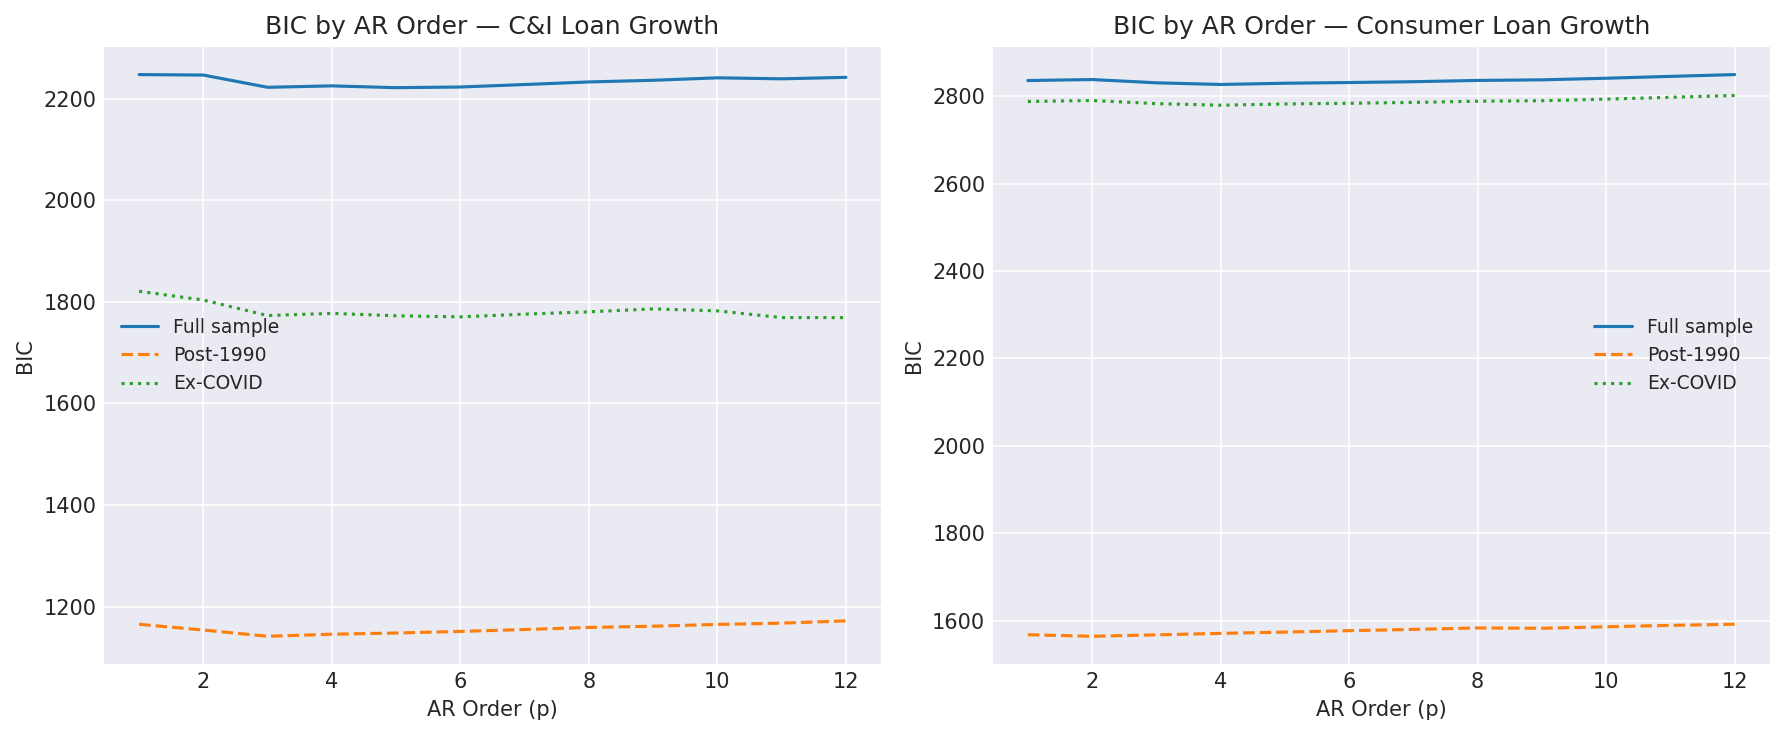

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes, ['BUSLOANS_g', 'CONSUMER_g'],
                           ['C&I Loan Growth', 'Consumer Loan Growth']):
    for sample, label, ls in [(growth, 'Full sample', '-'),
                               (growth.loc['1990-01-01':], 'Post-1990', '--'),
                               (g_excovid, 'Ex-COVID', ':')]:
        s = sample[col].dropna()
        bics = []
        for p in range(1, 13):
            try:
                m = AutoReg(s, lags=p, old_names=False).fit()
                bics.append(m.bic)
            except Exception:
                bics.append(np.nan)
        ax.plot(range(1, 13), bics, label=label, linestyle=ls)
    ax.set_xlabel('AR Order (p)')
    ax.set_ylabel('BIC')
    ax.set_title(f'BIC by AR Order — {title}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}bic_ar_selection.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 9. Cross-Correlation: Loan Growth vs. Macro Variables

Exploring which macro variables lead/lag loan growth helps justify feature selection for the VAR/ADL model (Phase 2).

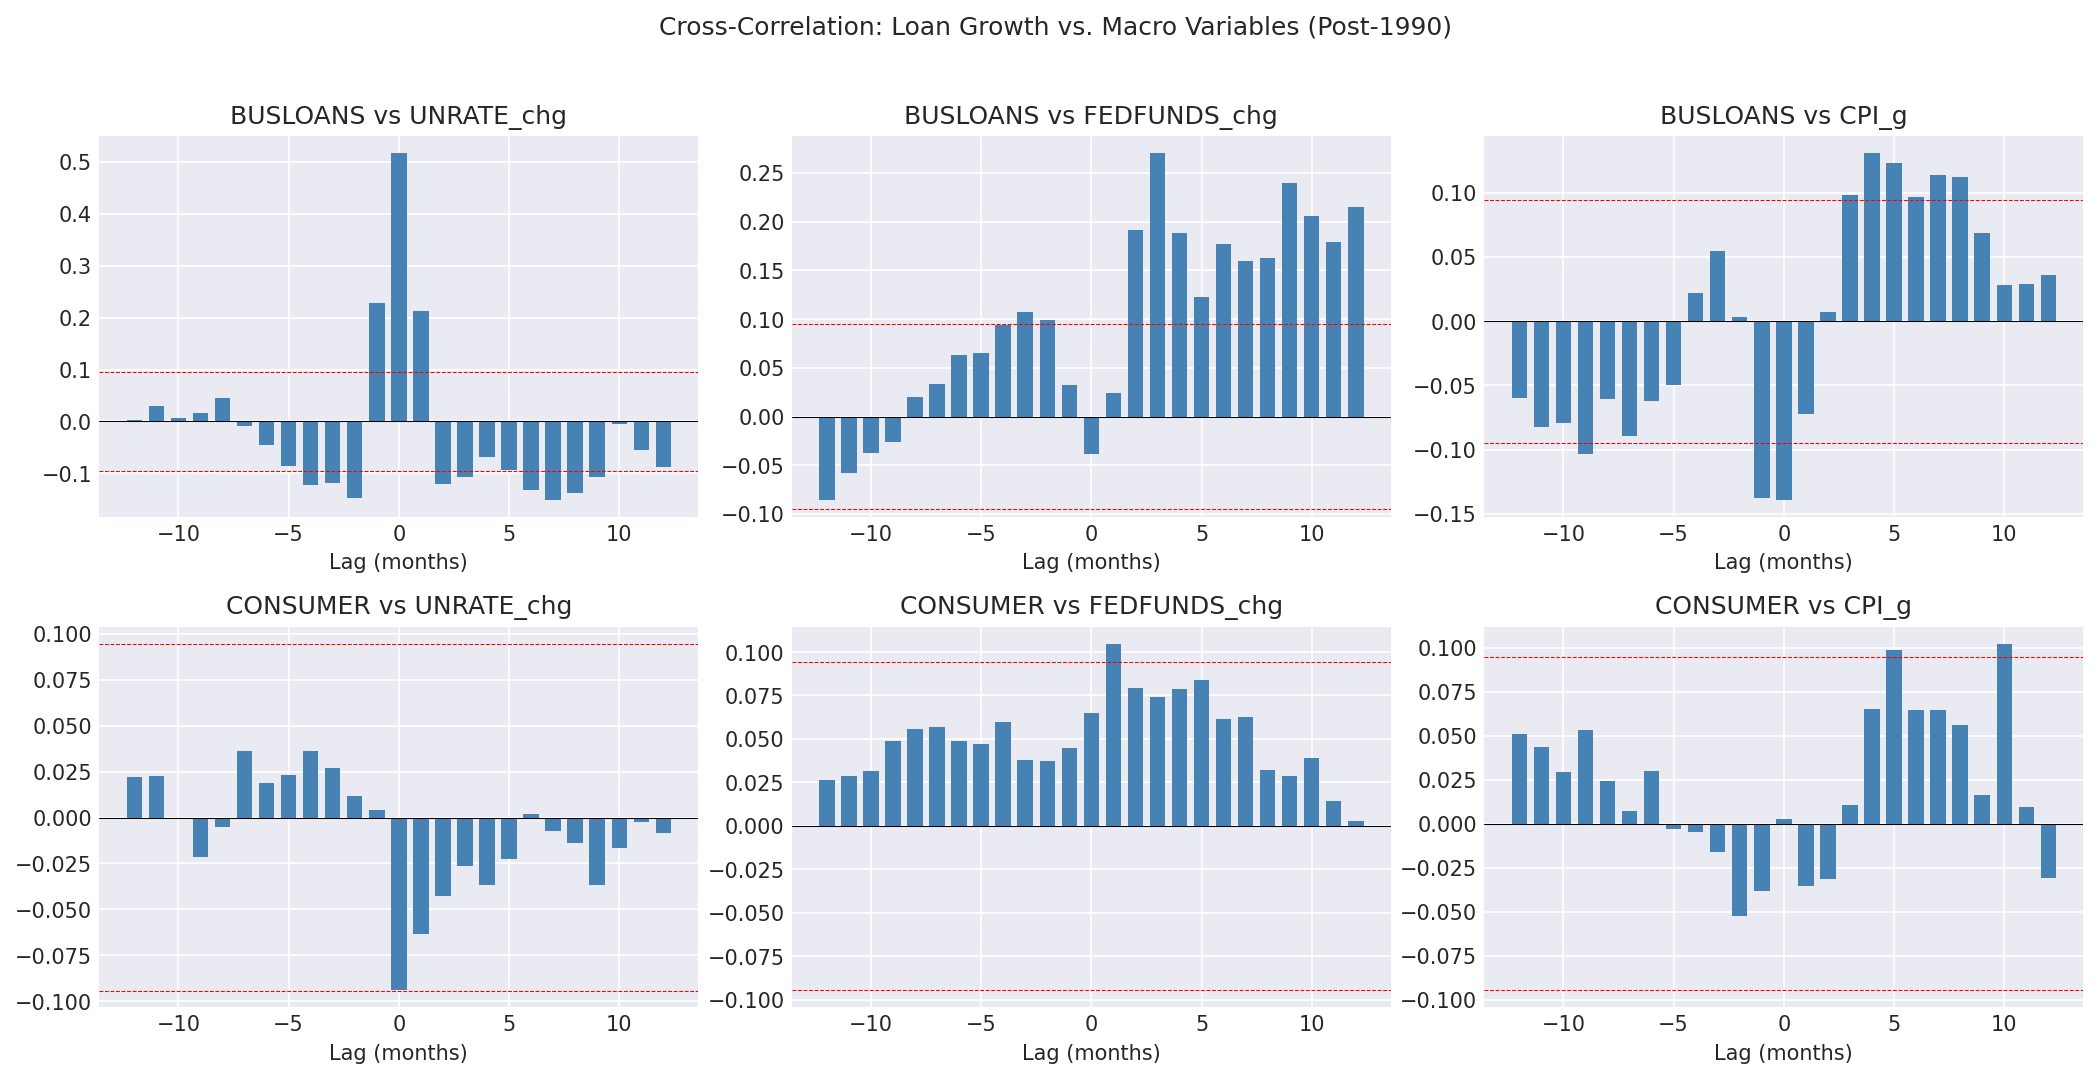

In [14]:
# Build a common monthly dataframe
monthly = growth[['BUSLOANS_g', 'CONSUMER_g']].copy()
# Add macro variables (levels and changes)
monthly = monthly.join(data['UNRATE'], how='left')
monthly = monthly.join(data['FEDFUNDS'], how='left')
monthly['UNRATE_chg'] = monthly['UNRATE'].diff()
monthly['FEDFUNDS_chg'] = monthly['FEDFUNDS'].diff()

# Add CPI inflation
monthly = monthly.join(cpi[['CPI_g']], how='left')

# Restrict to post-1990 for relevance
monthly_90 = monthly.loc['1990-01-01':].dropna()

# Cross-correlation at various lags
max_lag = 12
macro_vars = ['UNRATE_chg', 'FEDFUNDS_chg', 'CPI_g']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, loan_col in enumerate(['BUSLOANS_g', 'CONSUMER_g']):
    for j, macro_col in enumerate(macro_vars):
        ccf = [monthly_90[loan_col].corr(monthly_90[macro_col].shift(k)) for k in range(-max_lag, max_lag + 1)]
        axes[i, j].bar(range(-max_lag, max_lag + 1), ccf, color='steelblue', width=0.7)
        axes[i, j].axhline(0, color='black', linewidth=0.5)
        # Approximate 95% CI
        n = len(monthly_90)
        ci = 1.96 / np.sqrt(n)
        axes[i, j].axhline(ci, color='red', linewidth=0.5, linestyle='--')
        axes[i, j].axhline(-ci, color='red', linewidth=0.5, linestyle='--')
        axes[i, j].set_xlabel('Lag (months)')
        axes[i, j].set_title(f'{loan_col.replace("_g","")} vs {macro_col}')

plt.suptitle('Cross-Correlation: Loan Growth vs. Macro Variables (Post-1990)', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}cross_correlations.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 10. Rolling Statistics — Detecting Regime Changes

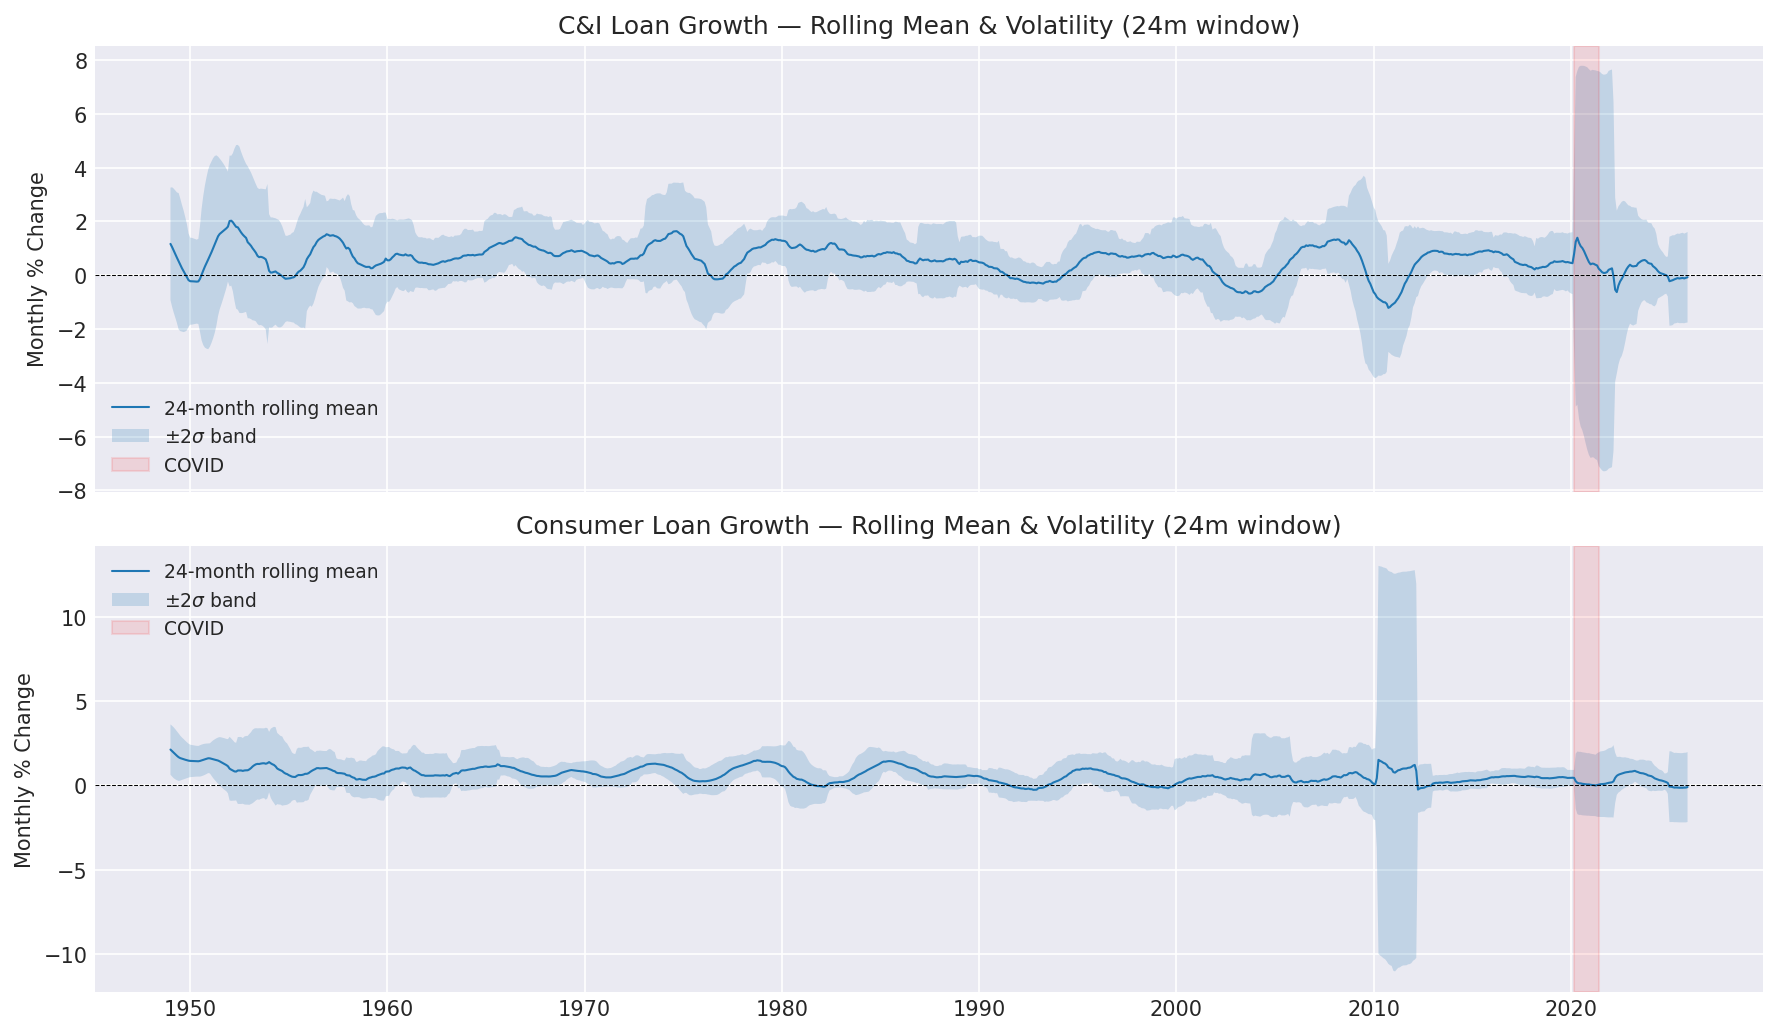

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, col, title in zip(axes, ['BUSLOANS_g', 'CONSUMER_g'],
                           ['C&I Loan Growth', 'Consumer Loan Growth']):
    roll_mean = growth[col].rolling(24).mean()
    roll_std = growth[col].rolling(24).std()
    ax.plot(growth.index, roll_mean, label='24-month rolling mean', linewidth=1)
    ax.fill_between(growth.index, roll_mean - 2*roll_std, roll_mean + 2*roll_std,
                    alpha=0.2, label='$\\pm 2\\sigma$ band')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), alpha=0.1, color='red', label='COVID')
    ax.set_ylabel('Monthly % Change')
    ax.set_title(f'{title} — Rolling Mean & Volatility (24m window)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}rolling_stats.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 11. Summary of Findings

| Finding | BUSLOANS (C&I) | CONSUMER |
|---------|---------------|----------|
| **Levels** | Non-stationary (ADF p=0.999, KPSS rejects) | Non-stationary (ADF p=1.000, KPSS rejects) |
| **Growth rates** | Stationary (ADF p<0.001) | Stationary (ADF p<0.001) |
| **Mean growth** | 0.58%/month (pre-COVID) | 0.68%/month (pre-COVID) |
| **COVID impact** | +13.0% spike (PPP lending, 13.9σ) | -3.5% drop (lockdown, 3.5σ) |
| **COVID asymmetry** | C&I surged UP (8 months > 3σ) | Consumer fell DOWN (1 month > 3σ) |
| **AR order (BIC, full)** | AR(5) | AR(4) |
| **AR order (BIC, ex-COVID)** | AR(12) — seasonal structure | AR(4) — stable |
| **Ljung-Box (ex-COVID AR)** | No residual autocorrelation (p>0.27) | No residual autocorrelation (p>0.59) |
| **Post-COVID mean** | 0.17%/month (↓73% from pre-COVID) | 0.32%/month (↓53% from pre-COVID) |

### Key Takeaways for Phase 2 Modeling

1. **Work in growth rates** — levels are I(1), growth rates are stationary
2. **COVID treatment is critical** — the structural break is asymmetric across C&I vs. consumer loans:
   - C&I: PPP lending caused a **+13% monthly spike** (Apr 2020), then sharp reversal as PPP loans were forgiven
   - Consumer: lockdowns caused a **-3.5% drop** (Apr 2020), more modest and symmetric
   - **Recommendation**: drop COVID observations OR include asymmetric COVID dummies — this is a strong Q&A question for BofA on Feb 20
3. **AR baselines are well-specified** — Ljung-Box tests confirm no remaining autocorrelation in residuals. These are the benchmarks any VAR/ADL model must beat.
4. **C&I loans show seasonal structure** (AR(12) preferred ex-COVID) — likely reflects calendar effects in commercial lending
5. **Post-COVID regime shift**: both loan series show materially lower mean growth rates post-2021 — the training window decision matters
6. **Cross-correlations** (see plots above) identify which macro variables to include in the multivariate model
7. **UNRATE and FEDFUNDS in levels** — unemployment is borderline stationary (ADF rejects at 5% but KPSS marginal); Fed Funds similar. Use changes in the VAR to be safe.

### Next Steps (Phase 2)
- **VAR model**: loan growth + unemployment change + Fed Funds change + CPI inflation
- **ADL model**: loan growth ~ own lags + distributed lags of macro variables
- **NGFS integration**: map NGFS scenario paths (GDP, carbon price) to the macro variables in the VAR
- **Forecast comparison**: AR baseline vs. VAR vs. ADL, evaluated by RMSE on hold-out sample